In [1]:
from langchain_google_genai import ChatGoogleGenerativeAI
import dotenv

dotenv.load_dotenv()


True

In [2]:
from langchain_core.tools import tool
# === Forbidden Topics ===
FORBIDDEN_TOPICS = ["violence", "murder", "sex", "drugs", "death", "blood", "war"]

# === TOOL: Fetch Story ===
@tool
def fetch_story(topic: str) -> str:
    """Returns a short story based on the given topic."""
    stories = {
        "sharing": "Benny the bunny shared his carrots and made everyone happy!",
        "kindness": "Lila helped an old man and started a kindness club!",
        "honesty": "Omar admitted his mistake and became trustworthy.",
        "violence": "Warriors fought in blood-soaked battles... (🚫 not for kids!)"
    }
    return stories.get(topic.lower(), "Sorry, no story is available for this topic.")

In [3]:
from langgraph.prebuilt import ToolNode
tools = [fetch_story]
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash").bind_tools(
    tools
)
tool_node = ToolNode(tools)

In [84]:
from pydantic import BaseModel, Field
from typing import List, Literal, Optional, Union
from langchain_core.messages import HumanMessage, AIMessage, BaseMessage

from typing import Annotated, List, Optional
from pydantic import BaseModel, Field
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages

class StoryState(BaseModel):
    messages: Annotated[List[BaseMessage], add_messages] = Field(default_factory=list)
    moderation_result: Annotated[Optional[str], add_messages] = None
    tool_result: Optional[BaseMessage] = None
    published: bool = False


In [85]:
# === Nodes ===
def moderate_topic_node(state: StoryState) -> StoryState:
    question = state.messages[-1].content
    prompt = (
        f"Return `true` if the following question is about any of these topics: "
        f"{', '.join(FORBIDDEN_TOPICS)}. Else return False.\n\nQuestion: {question}"
    )
    result = llm.invoke(prompt).content.strip().lower()
    state.moderation_result = result
    state.messages.append(AIMessage(content=result))
    return state

In [86]:
def should_continue_tool(state: StoryState) -> StoryState:
    if state.messages[-1].tool_calls:
        return "tools"
    return END

    # def should_continue_tool(state: StoryState) -> StoryState:
    # if state.messages[-1].tool_calls:
    #     return "tools"
    # return "generate_story"
    # return "reject_request"

def call_tool(state: StoryState) -> StoryState:

    # Save the tool response to the state
    tool_output = tool_node.invoke({"messages": state.messages})
    state.messages.extend(tool_output.get("messages", ""))
    print("1", state)
    return state


In [87]:
def reject_request(state: StoryState) -> StoryState:
    print("rejected!")
    state.moderation_result = 'true'
    return state

In [88]:
def should_continue_request(state: StoryState) -> StoryState:
    print(state.messages[-1].content )
    if state.messages[-1].content == 'true':
        return "reject_request"
    else:
        return "generate_story"

In [89]:
from langchain_core.messages import SystemMessage

def generate_story(state: StoryState) -> StoryState:
    system_msg = SystemMessage(
    content=(
        "You are a helpful assistant generating short stories for kids. "
        "If the user's request is appropriate and matches a known topic, and the AI evaluates the user question as `false`, "
        "then use the tool `fetch_story` to fetch the story. "
        "Do not rewrite or improve stories fetched from tools — keep them exactly as returned. "

        "However, if the tool returns a message like 'Sorry, no story is available for this topic.', "
        "then use your own knowledge to generate a short story (~100 words) based on the topic. "
    )
)


    # Append the system message to the message history
    state.messages.append(system_msg)

    # Let the model decide how to respond
    response = llm.invoke(state.messages)

    # Save the model response to the state
    state.messages.append(response)

    return state


In [90]:
from langgraph.graph import StateGraph, END, START


builder = StateGraph(StoryState)



builder.add_node("moderate_topic", moderate_topic_node)
builder.add_node("tools", call_tool)
builder.add_node("generate_story", generate_story)
builder.add_node("reject_request", reject_request)

builder.add_conditional_edges("moderate_topic", should_continue_request, {"reject_request":"reject_request", "generate_story":"generate_story"})
builder.add_conditional_edges("generate_story", should_continue_tool, {"tools":"tools",END:END})
# builder.add_conditional_edges("generate_story", should_continue_tool, {"tools":"tools", "reject_request":"reject_request"})
builder.add_edge("moderate_topic", "generate_story")
builder.add_edge("tools", "generate_story")
builder.add_edge("reject_request", END)
builder.set_entry_point("moderate_topic")

graph = builder.compile()

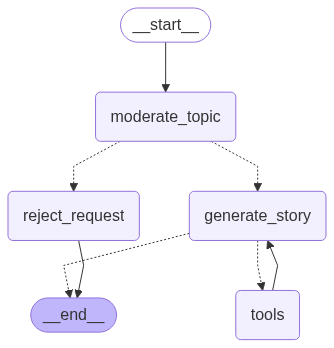

In [91]:
from IPython.display import Image, display
from langchain_core.runnables.graph import MermaidDrawMethod

display(
    Image(
        graph.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

In [92]:
from langchain_core.messages import HumanMessage

input_data = StoryState(messages=[HumanMessage(content="Give me a story on violence")])
result = graph.invoke(input=input_data, config={"configurable": {"thread_id": 1}})
result

true
rejected!


ValidationError: 1 validation error for StoryState
moderation_result
  Input should be a valid string [type=string_type, input_value=[HumanMessage(content='tr...d98-b733-3a4e07101e34')], input_type=list]
    For further information visit https://errors.pydantic.dev/2.11/v/string_type